In [3]:
import pandas as pd
from matplotlib import pyplot as plt

In [4]:
df = pd.read_csv('/Users/guita/Documents/TripleTen/Sprint7_WebApp/vehicles_us.csv')

In [5]:
df.info()
print()
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51525 entries, 0 to 51524
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   price         51525 non-null  int64  
 1   model_year    47906 non-null  float64
 2   model         51525 non-null  object 
 3   condition     51525 non-null  object 
 4   cylinders     46265 non-null  float64
 5   fuel          51525 non-null  object 
 6   odometer      43633 non-null  float64
 7   transmission  51525 non-null  object 
 8   type          51525 non-null  object 
 9   paint_color   42258 non-null  object 
 10  is_4wd        25572 non-null  float64
 11  date_posted   51525 non-null  object 
 12  days_listed   51525 non-null  int64  
dtypes: float64(4), int64(2), object(7)
memory usage: 5.1+ MB

   price  model_year           model  condition  cylinders fuel  odometer  \
0   9400      2011.0          bmw x5       good        6.0  gas  145000.0   
1  25500         NaN      for

In [6]:
print(df.isna().sum())

price               0
model_year       3619
model               0
condition           0
cylinders        5260
fuel                0
odometer         7892
transmission        0
type                0
paint_color      9267
is_4wd          25953
date_posted         0
days_listed         0
dtype: int64


1


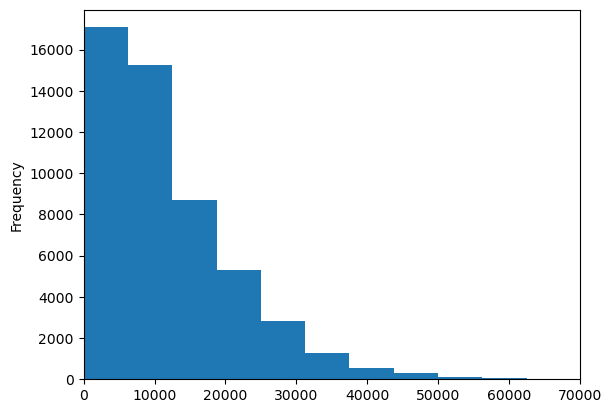

In [47]:
#vehicle_price = df.groupby('price')['model'].count()
#print(vehicle_price)
print(df['price'].min())
df['price'].plot(kind='hist',
        x='price',
        bins=60)
plt.xlim(0,70e3)
plt.show()

In [15]:
vehicle_model = df.pivot_table(index='model',aggfunc='count')['price']
print(vehicle_model)

model
acura tl             236
bmw x5               267
buick enclave        271
cadillac escalade    322
chevrolet camaro     414
                    ... 
toyota sienna        329
toyota tacoma        827
toyota tundra        603
volkswagen jetta     519
volkswagen passat    350
Name: price, Length: 100, dtype: int64


       fuel  type_quantity
1  electric              6
4     other            108
3    hybrid            409
0    diesel           3714
2       gas          47288


<Axes: xlabel='fuel'>

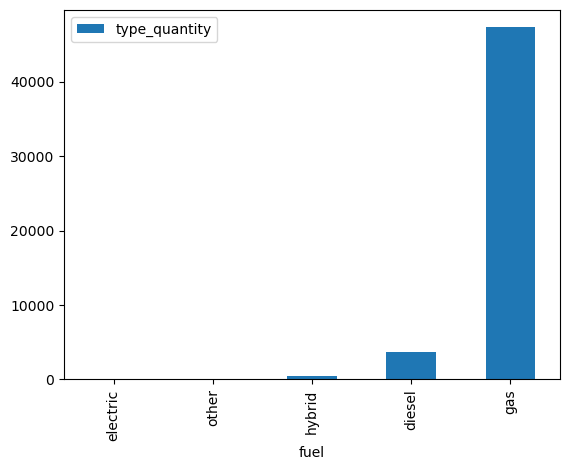

In [25]:
vehicle_fuel = df.groupby('fuel')['price'].count().reset_index(name='type_quantity').sort_values('type_quantity')
print(vehicle_fuel)
vehicle_fuel.plot(kind='bar',x='fuel')

   condition  condition_quantity
5    salvage                 115
4        new                 143
1       fair                1607
3   like new                4742
2       good               20145
0  excellent               24773


<Axes: xlabel='condition'>

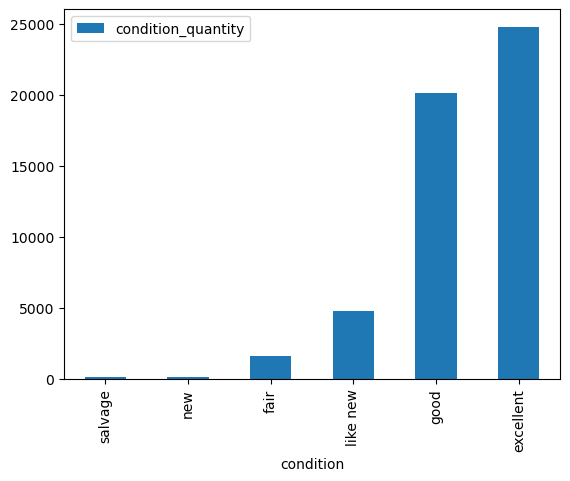

In [29]:
vehicle_condition = df.pivot_table(index='condition',aggfunc='count')['price'].reset_index(name='condition_quantity').sort_values('condition_quantity')
print(vehicle_condition)
vehicle_condition.plot(kind='bar',x='condition')

In [44]:
print(df[df['price'] < 10])

       price  model_year                model  condition  cylinders    fuel  \
405        1      2014.0     chevrolet camaro  excellent        6.0     gas   
3063       1      1998.0  chevrolet silverado       good        8.0     gas   
3808       1      2007.0      chevrolet tahoe       good        8.0     gas   
3902       1      1996.0           ford f-150       fair        NaN     gas   
4140       1      2004.0  chevrolet silverado  excellent        8.0  diesel   
...      ...         ...                  ...        ...        ...     ...   
49709      1         NaN            ford f150  excellent        8.0     gas   
50245      1      1986.0  chevrolet silverado       good        8.0     gas   
50393      1      2003.0    gmc sierra 2500hd       good        8.0  diesel   
50430      5      2011.0        toyota sienna       good        6.0     gas   
51256      1      2012.0       honda civic lx  excellent        4.0     gas   

       odometer transmission    type paint_color  i